# 1/3 (v6) — Dataset Collection: fixed scene, last-success anchor, raw 39-dim observation

Successful-only trajectories on a single frozen scene, labelled by counting
backward from the last confirmed success frame.

**Design decisions, and why:**

1. **Raw 39-dim observation, nothing added.** Earlier versions concatenated
   engineered columns (hand→peg vector, peg→goal vector, distances, a
   holding flag) onto the observation, making a 49-dim input. That's rolled
   back — `X` is now exactly what the environment returns, same as stage
   one. Derived quantities are still computed *at analysis time* for the
   diagnostics below, but they are never stored in the dataset and never
   handed to a model.
2. **Fixed scene, no domain randomization.** `RandomTaskSelectWrapper`
   resamples a new object/goal position on every reset — even with the same
   seed. It's turned off here and a single task is pinned, saved to
   `fixed_task.pkl` so notebooks 2 and 3 validate on the identical scene.
3. **Zero point = end of trajectory, anchored on the *last* success frame.**
   Roll out a short confirmation window past the first success, take the
   last confirmed success frame as the zero point, stop there. No 500-step
   flat-zero tail.
4. **No timestep anywhere near the model.** Frame index is used only to
   build the label (by walking the episode backward) and for the plots
   below — it is never a column in `X`.

Run top to bottom. Section 5 is a smoke test — check it before Section 6.
**Section 10 is the one that matters most**: it tests whether this dataset
actually contains more than one distinct trajectory, which decides whether
anything trained on it can generalize at all.

## 1. Imports and the observation contract

No feature builder. The index constants below exist so the *diagnostics* can
compute distances and a grasp flag for plotting — they are not used to build
`X`.

In [1]:
import gymnasium as gym
import metaworld
import numpy as np
import os, json, glob, pickle
import torch
from stable_baselines3 import SAC

In [2]:
# ============================================================
# The dataset stores the RAW environment observation, unchanged.
# These indices are for analysis/plotting only — nothing derived from them
# is ever written into X.
# ============================================================
HAND_POS_IDX = [0, 1, 2]
GRIPPER_IDX  = 3
PEG_POS_IDX  = [4, 5, 6]
GOAL_POS_IDX = [36, 37, 38]
GRIPPER_CLOSED_THRESHOLD = 0.6
OBS_DIM = 39

def derived_quantities(X_raw):
    """Analysis-time helper. Takes an (N, 39) block of raw observations and
    returns the interpretable quantities the plots below use. Deliberately
    NOT part of the dataset — call it on X after loading, never before
    saving."""
    hand = X_raw[:, HAND_POS_IDX]
    peg  = X_raw[:, PEG_POS_IDX]
    goal = X_raw[:, GOAL_POS_IDX]
    gripper = X_raw[:, GRIPPER_IDX]
    hand_to_peg = np.linalg.norm(peg - hand, axis=1)
    peg_to_goal = np.linalg.norm(goal - peg, axis=1)
    holding = ((gripper < GRIPPER_CLOSED_THRESHOLD) & (hand_to_peg < 0.06)).astype(np.float32)
    return dict(hand_to_peg=hand_to_peg, peg_to_goal=peg_to_goal,
                gripper=gripper, holding=holding)

In [3]:
TASK_NAME = "peg-insert-side-v3"
SUCCESS_KEY = "success"

def make_env(seed=0, render_mode=None):
    return gym.make("Meta-World/MT1", env_name=TASK_NAME, seed=seed, render_mode=render_mode)

_probe = make_env(seed=0)
DT = getattr(_probe.unwrapped, "dt", _probe.unwrapped.model.opt.timestep)
RAW_OBS_DIM = _probe.observation_space.shape[0]
_probe.close()
print(f"DT={DT} (logged for reference only — never a feature or a label unit)")
print(f"raw obs dim={RAW_OBS_DIM}, dataset feature dim={OBS_DIM}")
assert RAW_OBS_DIM == OBS_DIM, "environment observation is not 39-dim — check the metaworld version"

DT=0.0125 (logged for reference only — never a feature or a label unit)
raw obs dim=39, dataset feature dim=39


d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")


## 2. Fix the scene

`gym.make("Meta-World/MT1", ...)` wraps the env in a `RandomTaskSelectWrapper`
that resamples a brand-new object/goal position **every reset** — that's why
two rollouts with the same `seed` still started from different peg positions
in earlier versions. Here we reach into the wrapper chain once, turn that
resampling off, and pin a single task. The chosen task is pickled the first
time this runs, so re-running reproduces the identical scene rather than
picking a new one — and notebooks 2/3 load the same file.

In [4]:
OUTPUT_DIR = "./data/state_space_datasetV6"
os.makedirs(OUTPUT_DIR, exist_ok=True)
FIXED_TASK_PATH = os.path.join(OUTPUT_DIR, "fixed_task.pkl")

def find_wrapper(env, attr_name):
    """Walk the gym.Wrapper chain looking for the object that owns attr_name.
    Plain attribute access doesn't reliably forward through this stack
    (OrderEnforcing does not delegate), so walk `.env` explicitly."""
    w = env
    while not hasattr(w, attr_name):
        if not hasattr(w, "env"):
            raise AttributeError(f"no wrapper in the chain exposes {attr_name!r}")
        w = w.env
    return w

def make_fixed_scene_env(render_mode=None, task_index=0):
    env = make_env(seed=0, render_mode=render_mode)
    task_wrapper = find_wrapper(env, "tasks")
    task_wrapper.toggle_sample_tasks_on_reset(False)  # stop resampling on reset

    if os.path.exists(FIXED_TASK_PATH):
        with open(FIXED_TASK_PATH, "rb") as f:
            fixed_task = pickle.load(f)
    else:
        fixed_task = task_wrapper.tasks[task_index]
        with open(FIXED_TASK_PATH, "wb") as f:
            pickle.dump(fixed_task, f)

    env.unwrapped.set_task(fixed_task)
    return env

In [5]:
# The scene must be identical across resets, regardless of seed.
_env = make_fixed_scene_env()
_obs_a, _ = _env.reset(seed=1)
_obs_b, _ = _env.reset(seed=999)
_env.close()
same_scene = np.allclose(_obs_a[PEG_POS_IDX + GOAL_POS_IDX], _obs_b[PEG_POS_IDX + GOAL_POS_IDX])
print(f"peg/goal position identical across resets: {same_scene}")
assert same_scene, "scene is not actually fixed — check RandomTaskSelectWrapper wiring"
print(f"peg pos:  {_obs_a[PEG_POS_IDX]}")
print(f"goal pos: {_obs_a[GOAL_POS_IDX]}")
print(f"fixed task: {os.path.abspath(FIXED_TASK_PATH)}")

peg/goal position identical across resets: True
peg pos:  [0.11751744 0.6783546  0.03      ]
goal pos: [-0.28165585  0.63751751  0.13005779]
fixed task: e:\@ML_Projects\Peg_insertion\data\state_space_datasetV6\fixed_task.pkl


d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


## 3. Checkpoint selection

Checkpoint diversity is the main source of trajectory variety, since the scene no longer varies. Section 10 measures how much variety that actually buys.

In [6]:
checkpoint_paths = sorted(
    glob.glob("./checkpoints/peg_insert_side/sac_peg_insert_*.zip"),
    key=lambda p: int("".join(ch for ch in os.path.basename(p) if ch.isdigit()) or 0))

assert checkpoint_paths, (
    "No SAC checkpoints found in ./checkpoints/peg_insert_side/.\n"
    "This notebook rolls out trained expert policies to collect successful\n"
    "trajectories — it cannot run without them. `checkpoints/` is gitignored,\n"
    "so if it was deleted the policies must be retrained (or restored from a\n"
    "backup) before re-collecting.\n"
    "Section 10 does NOT need them: it reads the saved dataset from disk and\n"
    "can be run on its own.")

selected_checkpoints = list(dict.fromkeys([
    checkpoint_paths[0],
    checkpoint_paths[len(checkpoint_paths)//2],
    checkpoint_paths[-1],
]))
print(f"{len(checkpoint_paths)} checkpoints found, using {len(selected_checkpoints)}:")
for p in selected_checkpoints:
    print("  ", os.path.basename(p))

8 checkpoints found, using 3:
   sac_peg_insert_final.zip
   sac_peg_insert_400000.zip
   sac_peg_insert_700000.zip


## 4. Collection + labelling

`collect_fixed_scene_episode` runs until a short confirmation window past the
**first** success, then stops. It records every frame's success flag, so
`build_reverse_labels` can anchor on the **last** True frame rather than
assuming success is monotonic.

`build_reverse_labels` is the "end of trajectory = 0, walk backward" step:
start at the last-success frame (label 0) and count backward for every
earlier frame.

In [7]:
CONFIRM_BUFFER_FRAMES = 20  # frames kept past first success, to confirm it holds
MAX_STEPS = 500

def collect_fixed_scene_episode(model, env, deterministic, max_steps=MAX_STEPS,
                                 confirm_buffer=CONFIRM_BUFFER_FRAMES, seed=None):
    obs, _ = env.reset(seed=seed)
    obs_list, success_flags = [], []
    first_success = None
    frames_since_first_success = 0

    for t in range(max_steps):
        obs_list.append(obs.copy())
        action, _ = model.predict(obs, deterministic=deterministic)
        obs, reward, terminated, truncated, info = env.step(action)
        success_flags.append(bool(info.get(SUCCESS_KEY, 0)))

        if success_flags[-1] and first_success is None:
            first_success = t
        if first_success is not None:
            frames_since_first_success += 1
            if frames_since_first_success >= confirm_buffer:
                break
        if terminated or truncated:
            break

    if first_success is None:
        return None  # never succeeded — excluded, this dataset is successful-only

    return dict(obs_list=obs_list, success_flags=success_flags, first_success_idx=first_success)


def build_labels(success_flags):
    """Anchor on the FIRST success frame. Everything from there on is labelled 0
    (the task is done and stays done); earlier frames count backward to it.

    This replaces the previous last-success anchoring, which was degenerate.
    Because collection stops at first_success + confirm_buffer and success holds
    through that window, the LAST success frame was always the last frame of the
    episode — so 'count back from the last success' reduced exactly to
    label[t] = (n-1) - t, a pure frame counter with no state content. That is
    what produced the 93-97% clock-baseline skill and the perfectly linear
    ground-truth lines in the prediction plots.

    First-success anchoring gives the tail a flat 0 plateau instead of a
    countdown, which (a) breaks the label == frame-index identity and (b) gives
    the model explicit evidence that the value floors at 0 rather than
    continuing to decrease — the cause of negative predictions past the anchor.
    """
    n = len(success_flags)
    first_success_idx = min(i for i, s in enumerate(success_flags) if s)
    labels = np.zeros(n, dtype=np.float32)
    for t in range(n):
        labels[t] = float(max(0, first_success_idx - t))
    return labels, first_success_idx


def is_contiguous_success(success_flags, first_idx):
    """True if success held for every frame from first_idx to the end of the
    episode — i.e. no drop-and-return inside the confirmation buffer. If this
    is False, first_success fired prematurely and anchoring on it would place
    the 0 point before the task was really complete."""
    return all(success_flags[first_idx:])

## 5. Smoke test — check this before Section 6

In [ ]:
_scene_env = make_fixed_scene_env()
_m = SAC.load(selected_checkpoints[-1])
_ep = collect_fixed_scene_episode(_m, _scene_env, deterministic=False, seed=0)
_scene_env.close()

assert _ep is not None, "smoke-test episode failed to succeed at all — investigate before Section 6"
_first_idx = _ep["first_success_idx"]
_labels, _ = build_labels(_ep["success_flags"])
_contiguous = is_contiguous_success(_ep["success_flags"], _first_idx)
_obs0 = np.asarray(_ep["obs_list"][0], dtype=np.float32)
_n = len(_labels)

print(f"first success frame (anchor): {_first_idx}")
print(f"episode length collected: {_n} frames "
      f"({_n - _first_idx} frames at/after the anchor)")
print(f"success held continuously from anchor to end (no flicker): {_contiguous}")
print(f"label at frame 0: {_labels[0]}, at anchor: {_labels[_first_idx]} (expect 0), "
      f"at last frame: {_labels[-1]} (expect 0)")
print(f"stored observation shape: {_obs0.shape} (expect (39,) — raw, nothing appended)")

assert _obs0.shape[0] == OBS_DIM, "observation dim mismatch"
assert _labels[_first_idx] == 0, "anchor frame should be labelled 0"
assert _labels[-1] == 0, "post-anchor tail should be a flat 0 plateau"

# The check that matters: the label must NOT be a pure frame counter.
_pure_clock = np.arange(_n - 1, -1, -1, dtype=np.float32)
assert not np.allclose(_labels, _pure_clock), (
    "label is still identical to (n-1)-t — the degenerate case. The tail "
    "plateau is missing, so anchoring did not take effect.")
print(f"label is NOT a pure frame counter (differs on "
      f"{int((_labels != _pure_clock).sum())}/{_n} frames) — OK")
print("OK — proceed to Section 6")

## 6. Full collection

`deterministic=False` — with the scene fixed, a deterministic policy produces
the bit-for-bit identical rollout every time, so stochastic action sampling
(seeded via `torch.manual_seed`, reproducible run-to-run) is the only source
of within-checkpoint variety. Section 10 measures whether that is enough to
call these distinct trajectories.

In [8]:
EPISODES_PER_CHECKPOINT = 40
MAX_TRIES_PER_CKPT = EPISODES_PER_CHECKPOINT * 4

scene_env = make_fixed_scene_env()
episodes = []
episode_counter = 0

for ckpt in selected_checkpoints:
    ckpt_model = SAC.load(ckpt)
    tag = os.path.basename(ckpt)
    got, tries = 0, 0
    while got < EPISODES_PER_CHECKPOINT and tries < MAX_TRIES_PER_CKPT:
        torch.manual_seed(episode_counter)  # reproducible stochastic action sampling
        ep = collect_fixed_scene_episode(ckpt_model, scene_env, deterministic=False,
                                          seed=episode_counter)
        tries += 1
        episode_counter += 1
        if ep is not None:
            labels, first_idx = build_labels(ep["success_flags"])
            contiguous = is_contiguous_success(ep["success_flags"], first_idx)
            episodes.append(dict(obs_list=ep["obs_list"], labels=labels,
                                  first_success_idx=first_idx,
                                  contiguous=contiguous,
                                  source_ckpt=tag))
            got += 1
    print(f"{tag}: {got}/{EPISODES_PER_CHECKPOINT} collected in {tries} attempts")

scene_env.close()

anchor_idxs = [ep["first_success_idx"] for ep in episodes]
ep_lengths = [len(ep["obs_list"]) for ep in episodes]
n_noncontig = sum(not ep["contiguous"] for ep in episodes)

print(f"\nTotal: {len(episodes)} episodes")
print(f"anchor (first success) frame: min={min(anchor_idxs)}, max={max(anchor_idxs)}, "
      f"mean={np.mean(anchor_idxs):.1f}, std={np.std(anchor_idxs):.1f}")
print(f"episode length collected: min={min(ep_lengths)}, max={max(ep_lengths)}, "
      f"mean={np.mean(ep_lengths):.1f}")
print(f"episodes where success dropped after first firing: {n_noncontig}/{len(episodes)} "
      f"(if this is large, first-success anchoring is unsafe — the flag is premature)")

d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


sac_peg_insert_final.zip: 40/40 collected in 40 attempts
sac_peg_insert_400000.zip: 40/40 collected in 40 attempts
sac_peg_insert_700000.zip: 40/40 collected in 40 attempts

Total: 120 episodes
anchor (first success) frame: min=47, max=81, mean=58.8, std=12.8
episode length collected: min=67, max=101, mean=78.8
episodes where success dropped after first firing: 0/120 (if this is large, first-success anchoring is unsafe — the flag is premature)


## 7. Build rows — raw observation only

In [9]:
records = []
for ep_idx, ep in enumerate(episodes):
    for t, obs in enumerate(ep["obs_list"]):
        records.append(dict(
            episode_idx=ep_idx,
            frame_idx=t,              # for bookkeeping/plots only — never enters X
            steps_remaining=float(ep["labels"][t]),
            obs=np.asarray(obs, dtype=np.float32),   # raw, unchanged
        ))
print(f"Total rows: {len(records)}")
print(f"Avg frames/episode: {len(records)/len(episodes):.1f}")

Total rows: 9457
Avg frames/episode: 78.8


## 8. Save

In [10]:
X = np.stack([r["obs"] for r in records]).astype(np.float32)
y_steps = np.array([r["steps_remaining"] for r in records], dtype=np.float32)
episode_ids = np.array([r["episode_idx"] for r in records], dtype=np.int32)
frame_idxs = np.array([r["frame_idx"] for r in records], dtype=np.int32)
episode_sources = np.array([ep["source_ckpt"] for ep in episodes])

assert X.shape[1] == OBS_DIM, f"X should be {OBS_DIM}-dim raw observation, got {X.shape[1]}"

# X, the label, and the episode grouping. No engineered columns, no seconds,
# no timestep. frame_idxs and episode_sources are saved for diagnostics only —
# Section 10 uses them for the clock baseline and the per-checkpoint split;
# neither may ever be used as a model input.
np.savez(os.path.join(OUTPUT_DIR, "dataset.npz"),
         X=X, y_steps=y_steps, episode_ids=episode_ids,
         frame_idxs=frame_idxs, episode_sources=episode_sources)

n_zero_rows = int((y_steps == 0).sum())
source_of = [ep["source_ckpt"] for ep in episodes]

summary = dict(
    total_rows=int(len(records)),
    total_episodes=int(len(episodes)),
    feature_dim=int(X.shape[1]),
    feature_content="raw 39-dim environment observation, nothing appended",
    dt_sec=float(DT),
    fixed_scene=True,
    fixed_task_path=os.path.abspath(FIXED_TASK_PATH),
    sources_used=sorted(set(source_of)),
    checkpoint_diversity=len(set(source_of)) > 1,
    label_anchor="first_success_frame",
    label_tail="flat zero plateau from anchor to end of episode",
    confirm_buffer_frames=CONFIRM_BUFFER_FRAMES,
    avg_frames_per_episode=round(len(records)/len(episodes), 1),
    anchor_frame_min=int(min(anchor_idxs)),
    anchor_frame_max=int(max(anchor_idxs)),
    anchor_frame_std=float(np.std(anchor_idxs)),
    noncontiguous_success_episodes=int(sum(not ep["contiguous"] for ep in episodes)),
        zero_label_row_fraction=round(n_zero_rows / len(records), 4),
)
with open(os.path.join(OUTPUT_DIR, "dataset_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2))

{
  "total_rows": 9457,
  "total_episodes": 120,
  "feature_dim": 39,
  "feature_content": "raw 39-dim environment observation, nothing appended",
  "dt_sec": 0.0125,
  "fixed_scene": true,
  "fixed_task_path": "e:\\@ML_Projects\\Peg_insertion\\data\\state_space_datasetV6\\fixed_task.pkl",
  "sources_used": [
    "sac_peg_insert_400000.zip",
    "sac_peg_insert_700000.zip",
    "sac_peg_insert_final.zip"
  ],
  "checkpoint_diversity": true,
  "label_anchor": "first_success_frame",
  "label_tail": "flat zero plateau from anchor to end of episode",
  "confirm_buffer_frames": 20,
  "avg_frames_per_episode": 78.8,
  "anchor_frame_min": 47,
  "anchor_frame_max": 81,
  "anchor_frame_std": 12.834391190166452,
  "noncontiguous_success_episodes": 0,
  "zero_label_row_fraction": 0.2538
}


## 9. Basic sanity checks

Label shape, flicker, grasp timing. All derived quantities here are computed
from the raw observation at analysis time — none of them live in `X`.

In [11]:
import matplotlib.pyplot as plt

der = derived_quantities(X)
hand_to_peg, peg_to_goal, holding = der["hand_to_peg"], der["peg_to_goal"], der["holding"]

print(f"zero-label rows: {n_zero_rows}/{len(records)} ({100*n_zero_rows/len(records):.1f}%)")
print(f"episodes with non-contiguous success: "
      f"{sum(not ep['contiguous'] for ep in episodes)}/{len(episodes)}")
print(f"holding=1 fraction (derived at analysis time): {holding.mean():.1%}")

grasp_frames, multi, missing = [], 0, 0
for ep in np.unique(episode_ids):
    h = holding[episode_ids == ep]
    onsets = np.where(np.diff(h) > 0)[0]
    if len(onsets) == 0:
        missing += 1
    else:
        grasp_frames.append(onsets[0])
        if len(onsets) > 1:
            multi += 1
grasp_frames = np.array(grasp_frames)
print(f"grasp detected: {len(grasp_frames)}/{len(np.unique(episode_ids))}, "
      f"no grasp: {missing}, multiple transitions: {multi}")
print(f"grasp frame: mean={grasp_frames.mean():.1f}, min={grasp_frames.min()}, max={grasp_frames.max()}")

zero-label rows: 2400/9457 (25.4%)
episodes with non-contiguous success: 0/120
holding=1 fraction (derived at analysis time): 60.7%
grasp detected: 120/120, no grasp: 0, multiple transitions: 0
grasp frame: mean=29.9, min=25, max=43


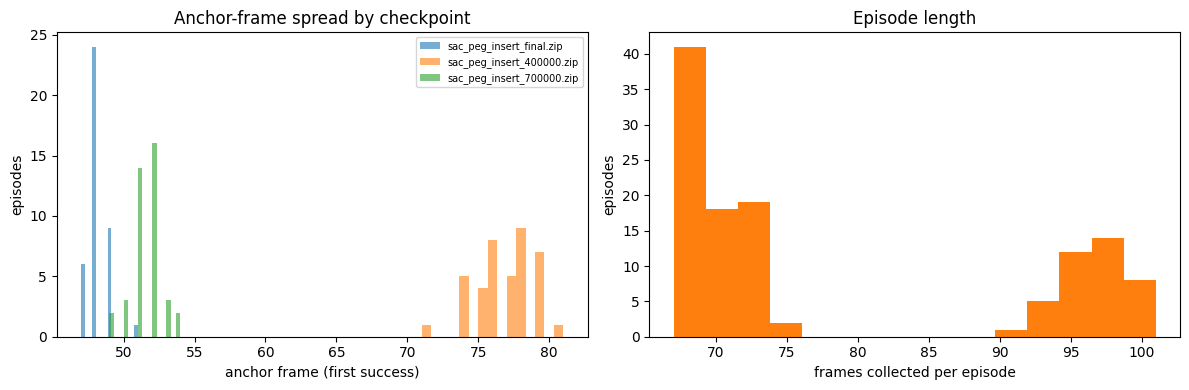

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

by_source = {}
for ep in episodes:
    by_source.setdefault(ep["source_ckpt"], []).append(ep["first_success_idx"])
for tag, vals in by_source.items():
    ax[0].hist(vals, bins=15, alpha=0.6, label=tag)
ax[0].set_xlabel("anchor frame (first success)"); ax[0].set_ylabel("episodes")
ax[0].set_title("Anchor-frame spread by checkpoint")
ax[0].legend(fontsize=7)

ax[1].hist(ep_lengths, bins=15, color="tab:orange")
ax[1].set_xlabel("frames collected per episode"); ax[1].set_ylabel("episodes")
ax[1].set_title("Episode length")
plt.tight_layout(); plt.show()

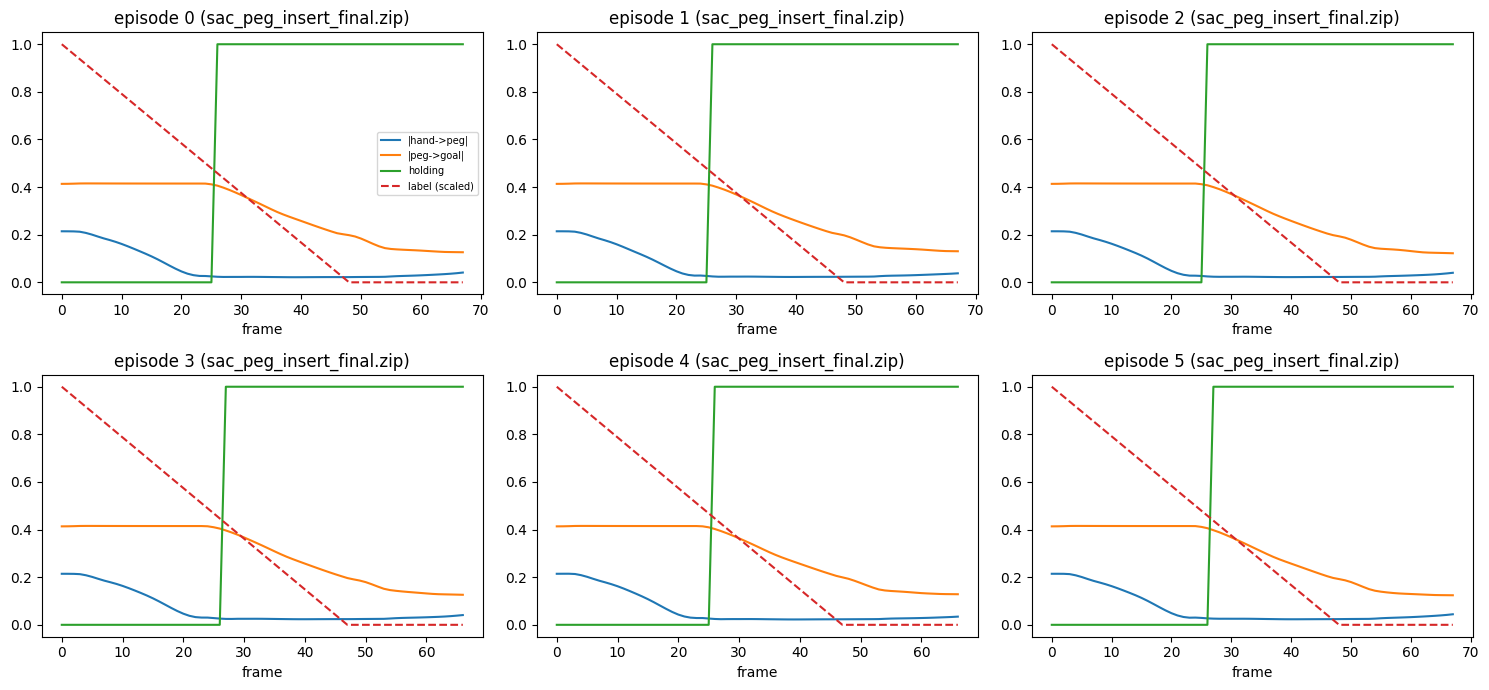

In [13]:
sample_eps = sorted(set(episode_ids.tolist()))[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax_, ep_idx in zip(axes.flat, sample_eps):
    m = episode_ids == ep_idx
    ax_.plot(hand_to_peg[m], label="|hand->peg|")
    ax_.plot(peg_to_goal[m], label="|peg->goal|")
    ax_.plot(holding[m], label="holding")
    denom = max(y_steps[m].max(), 1)
    ax_.plot(y_steps[m] / denom, "--", label="label (scaled)")
    ax_.set_title(f"episode {ep_idx} ({episodes[ep_idx]['source_ckpt']})")
    ax_.set_xlabel("frame")
axes.flat[0].legend(fontsize=7)
plt.tight_layout(); plt.show()

## 10. Structure proof — does this dataset contain more than one trajectory?

This is the section that decides whether anything trained on this data can
generalize. The scene is frozen and the policies are near-deterministic, so
the real question is whether 120 episodes are 120 *distinct* trajectories or
one trajectory sampled 120 times with jitter.

Five tests, each answering something different:

- **A. Dead columns.** With a fixed scene, how many of the 39 observation
  dimensions never change? Those carry zero information.
- **B. Cross-episode spread.** Aligned by frame index, how far apart are the
  episodes, measured against the distance the hand actually travels?
- **C. Pairwise trajectory distance.** Within a checkpoint vs across
  checkpoints — does stochastic sampling produce genuinely different paths,
  or only checkpoint choice does?
- **D. Intrinsic dimensionality.** How many PCA components cover the state
  cloud? A single path shows up as an essentially 1-D filament.
- **E. The clock test.** Can the label be predicted from frame index alone,
  ignoring the state entirely? If yes, then state→label is indistinguishable
  from counting frames on this data, and a model fit to it has learned a
  clock, not task progress.

This section reads the saved dataset from disk, so it runs standalone — no
need to re-run the collection above (and no need for the SAC checkpoints).

In [ ]:
# Self-contained: load the saved dataset rather than depending on the
# in-memory state from Sections 6-8.
import matplotlib.pyplot as plt

_d = np.load(os.path.join(OUTPUT_DIR, "dataset.npz"))
X = _d["X"]
y_steps = _d["y_steps"]
episode_ids = _d["episode_ids"]
frame_idxs = _d["frame_idxs"]
episode_sources = _d["episode_sources"]

with open(os.path.join(OUTPUT_DIR, "dataset_summary.json")) as f:
    _summary = json.load(f)

OBS_DIM = X.shape[1]
n_eps = len(np.unique(episode_ids))
source_of = list(episode_sources)
print(f"loaded {X.shape[0]} rows x {OBS_DIM} dims, {n_eps} episodes, "
      f"{len(set(source_of))} source checkpoints")
print(f"feature content: {_summary.get('feature_content', 'unknown')}")

In [ ]:
# --- A. Dead columns: dimensions that never vary on a fixed scene ---
# Threshold matters here. Some columns are bit-identical (std exactly 0), but the
# goal columns carry float32 rounding jitter of ~1e-5 while being physically
# constant. Treating those as "informative" would let PCA below rescale pure
# numerical noise to unit variance and inflate the apparent dimensionality, so
# the cutoff is physical (0.1 mm in position units), not numerical.
EPS_CONST = 1e-4
col_std = X.std(axis=0)
exactly_zero = np.where(col_std == 0.0)[0]
dead = np.where(col_std < EPS_CONST)[0]
alive = np.where(col_std >= EPS_CONST)[0]

print(f"bit-identical columns (std == 0):       {len(exactly_zero)}/{OBS_DIM}")
print(f"physically constant (std < {EPS_CONST:g}):    {len(dead)}/{OBS_DIM}")
print(f"  constant dims: {dead.tolist()}")
print(f"informative dims: {len(alive)}/{OBS_DIM} -> {alive.tolist()}")
print()
print(f"goal cols {GOAL_POS_IDX} std = {np.round(col_std[GOAL_POS_IDX], 8).tolist()}")
print("  -> constant, as expected: the scene is fixed. (Non-zero only from float32 jitter.)")
print(f"peg cols {PEG_POS_IDX} std = {np.round(col_std[PEG_POS_IDX], 5).tolist()}")
print("  -> genuinely varying, as expected: the peg is picked up and moved during the episode.")
print()
print(f"So although X is 39-dim as required, only {len(alive)} dims carry signal on a fixed scene.")

In [ ]:
# --- B. Cross-episode spread, aligned by frame index ---
ep_rows = [np.where(episode_ids == e)[0] for e in range(n_eps)]
common_len = min(len(r) for r in ep_rows)
hand_xyz = X[:, HAND_POS_IDX]

# (n_eps, common_len, 3) stack of hand paths
H = np.stack([hand_xyz[r[:common_len]] for r in ep_rows])

# how far the hand travels within one episode — the scale everything else is measured against
path_len = np.linalg.norm(np.diff(H, axis=1), axis=2).sum(axis=1).mean()

# at each frame index, how far apart are episodes from their own mean?
per_frame_spread = np.linalg.norm(H - H.mean(axis=0, keepdims=True), axis=2).mean(axis=0)

print(f"mean hand path length per episode: {path_len:.4f} m")
print(f"mean cross-episode spread at a given frame: {per_frame_spread.mean():.4f} m "
      f"({100*per_frame_spread.mean()/path_len:.1f}% of path length)")
print(f"max spread at any single frame: {per_frame_spread.max():.4f} m")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(per_frame_spread, label="mean cross-episode spread of hand position")
ax.axhline(path_len, color="tab:red", linestyle="--", label=f"hand path length ({path_len:.3f} m)")
ax.set_xlabel("frame index"); ax.set_ylabel("metres")
ax.set_title("How different are the episodes at the same point in time?")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

In [ ]:
# --- C. Pairwise trajectory distance, within vs across checkpoints ---
order = np.argsort([source_of[e] for e in range(n_eps)], kind="stable")
H_sorted = H[order]
tags_sorted = [source_of[e] for e in order]

D = np.zeros((n_eps, n_eps), dtype=np.float32)
for i in range(n_eps):
    D[i] = np.linalg.norm(H_sorted - H_sorted[i][None], axis=2).mean(axis=1)

same_ckpt = np.array([[tags_sorted[i] == tags_sorted[j] for j in range(n_eps)] for i in range(n_eps)])
off_diag = ~np.eye(n_eps, dtype=bool)
within = D[same_ckpt & off_diag]
across = D[(~same_ckpt) & off_diag]

print(f"mean pairwise trajectory distance WITHIN the same checkpoint: {within.mean():.5f} m "
      f"({100*within.mean()/path_len:.2f}% of path length)")
print(f"mean pairwise trajectory distance ACROSS checkpoints:        {across.mean():.5f} m "
      f"({100*across.mean()/path_len:.2f}% of path length)")
print(f"ratio across/within: {across.mean()/max(within.mean(), 1e-9):.1f}x")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(D, cmap="viridis")
ax.set_title("Pairwise trajectory distance\n(episodes sorted by checkpoint)")
ax.set_xlabel("episode"); ax.set_ylabel("episode")
plt.colorbar(im, ax=ax, label="mean hand distance (m)")
plt.tight_layout(); plt.show()

In [ ]:
# --- D. Intrinsic dimensionality of the state cloud ---
from sklearn.decomposition import PCA

X_alive = X[:, alive]
X_n = (X_alive - X_alive.mean(axis=0)) / (X_alive.std(axis=0) + 1e-8)
pca = PCA().fit(X_n)
cum = np.cumsum(pca.explained_variance_ratio_)
n90 = int(np.searchsorted(cum, 0.90) + 1)
n95 = int(np.searchsorted(cum, 0.95) + 1)

print(f"PCA over the {len(alive)} informative dims:")
print(f"  PC1 alone explains {100*pca.explained_variance_ratio_[0]:.1f}% of variance")
print(f"  components needed for 90% variance: {n90}")
print(f"  components needed for 95% variance: {n95}")

Z = pca.transform(X_n)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(np.arange(1, len(cum)+1), cum, marker="o", ms=3)
axes[0].axhline(0.95, color="tab:red", linestyle="--", label="95%")
axes[0].set_xlabel("PCA components"); axes[0].set_ylabel("cumulative explained variance")
axes[0].set_title("Intrinsic dimensionality"); axes[0].legend(fontsize=8)

sc = axes[1].scatter(Z[:, 0], Z[:, 1], c=y_steps, s=3, cmap="viridis")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
axes[1].set_title("State cloud, coloured by label\n(a single filament = one path repeated)")
plt.colorbar(sc, ax=axes[1], label="steps remaining")
plt.tight_layout(); plt.show()

In [ ]:
# --- E. The clock test: predict the label from frame index alone ---
# Baseline that ignores the state entirely: at frame t, predict the median
# label across all episodes at frame t. If this is nearly as good as anything
# a state-based model could do, then on this data "state -> time to success"
# is indistinguishable from counting frames.
max_len = int(frame_idxs.max()) + 1
clock_table = np.zeros(max_len, dtype=np.float32)
for t in range(max_len):
    vals = y_steps[frame_idxs == t]
    clock_table[t] = np.median(vals) if len(vals) else 0.0

clock_pred = clock_table[frame_idxs]
mae_clock = np.abs(clock_pred - y_steps).mean()
mae_mean_baseline = np.abs(y_steps.mean() - y_steps).mean()

print(f"label std over the dataset:            {y_steps.std():.2f} steps")
print(f"MAE predicting the global mean label:  {mae_mean_baseline:.2f} steps")
print(f"MAE predicting from FRAME INDEX only:  {mae_clock:.2f} steps")
print(f"  -> the clock explains "
      f"{100*(1 - mae_clock/mae_mean_baseline):.1f}% of what the mean baseline leaves on the table")

# The global number UNDERSTATES the problem: the three checkpoints reach success
# at different frames, so one global clock cannot fit all three at once. The
# honest test is per-checkpoint — within a single policy, is the label just a
# function of frame index?
print("\nper-checkpoint clock test (the number that actually matters):")
src_row = np.array([source_of[e] for e in episode_ids])
group_skill = {}
for g in sorted(set(source_of)):
    m = src_row == g
    yy, ff = y_steps[m], frame_idxs[m]
    tab = np.zeros(int(ff.max()) + 1, dtype=np.float32)
    for t in range(len(tab)):
        v = yy[ff == t]
        tab[t] = np.median(v) if len(v) else 0.0
    g_mae = np.abs(tab[ff] - yy).mean()
    g_base = np.abs(yy.mean() - yy).mean()
    group_skill[g] = 1 - g_mae / g_base
    print(f"  {g:28s} clock MAE={g_mae:6.3f} steps  (label std {yy.std():5.2f})  "
          f"skill {group_skill[g]:6.1%}")
worst_group_skill = min(group_skill.values())

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(frame_idxs, y_steps, s=2, alpha=0.15, label="actual labels")
ax.plot(clock_table[:max_len], color="tab:red", lw=2, label="clock baseline (median label per frame)")
ax.set_xlabel("frame index"); ax.set_ylabel("steps remaining (label)")
ax.set_title("Can a clock explain the labels?")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

In [ ]:
# --- Verdict ---
spread_pct = 100 * per_frame_spread.mean() / path_len
within_pct = 100 * within.mean() / path_len
clock_skill = 1 - mae_clock / mae_mean_baseline

print("=" * 68)
print("STRUCTURE VERDICT")
print("=" * 68)
print(f"A. informative dims:            {len(alive)}/{OBS_DIM} "
      f"({len(dead)} frozen by the fixed scene)")
print(f"B. cross-episode spread:        {spread_pct:.1f}% of hand path length")
print(f"C. within-checkpoint distance:  {within_pct:.2f}% of path length "
      f"(across-checkpoint is {across.mean()/max(within.mean(),1e-9):.1f}x larger)")
print(f"D. PCA components for 95% var:  {n95} (PC1 alone: "
      f"{100*pca.explained_variance_ratio_[0]:.1f}%)")
print(f"E. clock baseline (global):     MAE {mae_clock:.2f} steps vs label std {y_steps.std():.2f} "
      f"(skill {clock_skill:.1%})")
print(f"   clock baseline (per-ckpt):   skill {min(group_skill.values()):.1%} to "
      f"{max(group_skill.values()):.1%}  <-- the honest number")
print()

verdicts = []
if within_pct < 5:
    verdicts.append("Episodes from the same checkpoint are nearly identical — stochastic\n"
                    "   action sampling is NOT producing meaningfully different paths.")
if across.mean() / max(within.mean(), 1e-9) > 3:
    verdicts.append("Essentially all diversity comes from checkpoint choice, so this is\n"
                    f"   closer to {len(set(source_of))} distinct trajectories than to {n_eps}.")
if n95 <= 5:
    verdicts.append(f"The state cloud is {n95}-dimensional — the data lies on a thin\n"
                    "   filament, not a volume.")
if worst_group_skill > 0.8:
    verdicts.append("Within a single checkpoint, a frame counter predicts the label to within\n"
                    f"   ~1 step (skill >= {worst_group_skill:.0%}). State -> time-to-success is NOT\n"
                    "   separable from elapsed time on this data: any model fit here can score\n"
                    "   near-perfectly by learning 'where am I along the one path', which is\n"
                    "   exactly what held-out-EPISODE validation cannot catch when every episode\n"
                    "   is the same path.")

if verdicts:
    print("Findings:")
    for v in verdicts:
        print(f" - {v}")
else:
    print("No degeneracy flags raised — the dataset covers meaningfully distinct trajectories.")
print("=" * 68)

## 11. Reminders for what comes next

- **`fixed_task.pkl` is the scene contract.** Notebooks 2 and 3 load it to
  validate on the identical scene. It is *not* regenerated when this notebook
  re-runs (the loader reuses the existing file), so the scene is stable
  across every re-collection.
- **`X` is now 39-dim raw observation.** Downstream notebooks that assumed a
  49-dim engineered vector (`build_features`, `FEATURE_DIM = 49`) will fail
  their dimension assertion until they're updated to consume the raw
  observation. That assertion firing is the intended behaviour — it's loud,
  not silent.
- **Read Section 10 before training anything on this.** If the structure
  verdict flags degeneracy, a model fit to this data will look excellent on
  held-out *frames* while having learned only where it is along one repeated
  path — which held-out-episode validation cannot detect when every episode
  is the same path.

- **Provenance of the dataset currently on disk.** `checkpoints/` was deleted
  (it is gitignored), so the SAC expert policies this notebook rolls out are
  gone and Sections 1-9 cannot re-run until they are retrained or restored.
  The 39-dim `dataset.npz` in `data/state_space_datasetV6/` was therefore
  derived from the previous 49-column dataset by taking columns 0:39 — which
  is exactly identical to what a re-collection would produce, because those
  columns were always the untouched raw observation (verified: every
  engineered column 39-48 is reconstructible from 0-38). The original file is
  preserved as `dataset_49col_original.npz`, and `dataset_summary.json`
  records this under `derived_from`.